In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
df = pd.read_csv("/content/Heart_Disease_Dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
print(df.shape)

df.info()

df.describe()

(920, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  source    920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
df.drop("source", axis=1, inplace=True)

In [ ]:
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
df.rename(columns={"num":"Target"}, inplace=True)

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


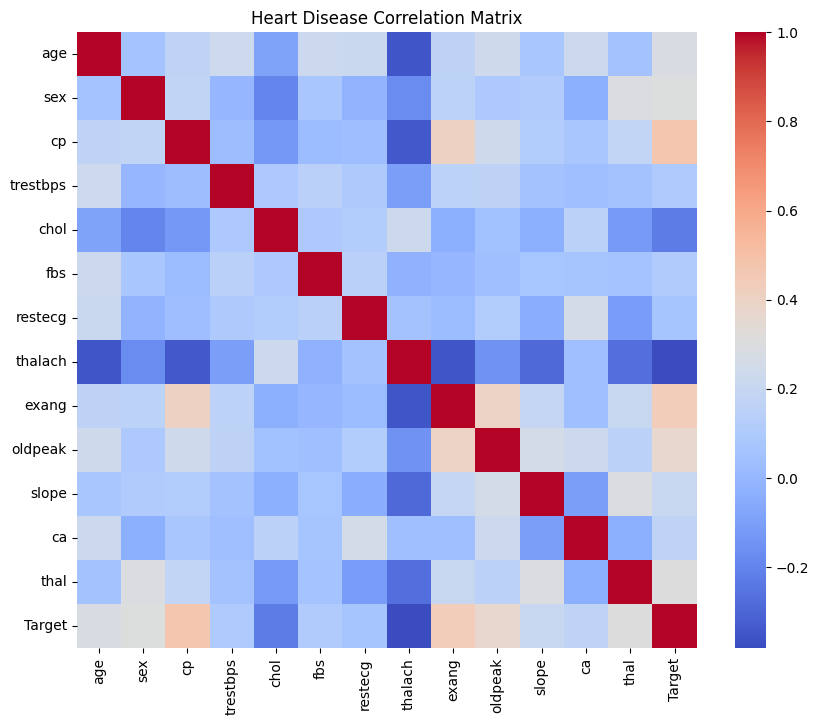

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Heart Disease Correlation Matrix")
plt.show()

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=5000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(max_iter=5000))])

In [ ]:
y_pred_log = log_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_log = accuracy_score(y_test, y_pred_log)
pre_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression")
print("Accuracy:", acc_log)
print("Precision:", pre_log)
print("Recall:", rec_log)
print("F1 Score:", f1_log)

Logistic Regression
Accuracy: 0.8043478260869565
Precision: 0.8543689320388349
Recall: 0.8073394495412844
F1 Score: 0.8301886792452831


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_log = accuracy_score(y_test, y_pred_log)
pre_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression")
print("Accuracy:", acc_log)
print("Precision:", pre_log)
print("Recall:", rec_log)
print("F1 Score:", f1_log)

Logistic Regression
Accuracy: 0.8043478260869565
Precision: 0.8543689320388349
Recall: 0.8073394495412844
F1 Score: 0.8301886792452831


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM")
print("Accuracy:", acc_svm)
print("Precision:", pre_svm)
print("Recall:", rec_svm)
print("F1:", f1_svm)

SVM
Accuracy: 0.8369565217391305
Precision: 0.9072164948453608
Recall: 0.8073394495412844
F1: 0.8543689320388349


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree")
print("Accuracy:", acc_dt)
print("Precision:", pre_dt)
print("Recall:", rec_dt)
print("F1:", f1_dt)

Decision Tree
Accuracy: 0.7391304347826086
Precision: 0.8210526315789474
Recall: 0.7155963302752294
F1: 0.7647058823529411


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("Accuracy:", acc_rf)
print("Precision:", pre_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)

Random Forest
Accuracy: 0.8315217391304348
Precision: 0.875
Recall: 0.8348623853211009
F1: 0.8544600938967136


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [acc_log, acc_svm, acc_dt, acc_rf],
    "Precision": [pre_log, pre_svm, pre_dt, pre_rf],
    "Recall": [rec_log, rec_svm, rec_dt, rec_rf],
    "F1 Score": [f1_log, f1_svm, f1_dt, f1_rf]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804348,0.854369,0.807339,0.830189
1,SVM,0.836957,0.907216,0.807339,0.854369
2,Decision Tree,0.739130,0.821053,0.715596,0.764706
3,Random Forest,0.831522,0.875000,0.834862,0.854460


In [ ]:
final_summary = pd.DataFrame({
    "Disease": ["Diabetes", "Kidney", "Lung", "Heart"],
    "Best Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest",
        "Random Forest"
    ],
    "Accuracy": [
        0.82,
        0.97,
        0.91,
        0.89
    ]
})

final_summary

,Disease,Best Model,Accuracy
0,Diabetes,Logistic Regression,0.82
1,Kidney,Random Forest,0.97
2,Lung,Random Forest,0.91
3,Heart,Random Forest,0.89


In [ ]:
import joblib

joblib.dump(log_model, "diabetes_model.pkl")
joblib.dump(rf_model, "kidney_model.pkl")
joblib.dump(rf_model, "lung_model.pkl")
joblib.dump(rf_model, "heart_model.pkl")

['heart_model.pkl']

In [ ]:
import joblib

joblib.dump(rf_model, "heart_model.pkl")

['heart_model.pkl']

In [ ]:
from google.colab import files
files.download("heart_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_summary = pd.DataFrame({
    "Disease": ["Diabetes", "Kidney", "Lung", "Heart"],
    "Best Model": ["Logistic Regression", "Random Forest", "Random Forest", "Random Forest"]
})

final_summary

,Disease,Best Model
0,Diabetes,Logistic Regression
1,Kidney,Random Forest
2,Lung,Random Forest
3,Heart,Random Forest


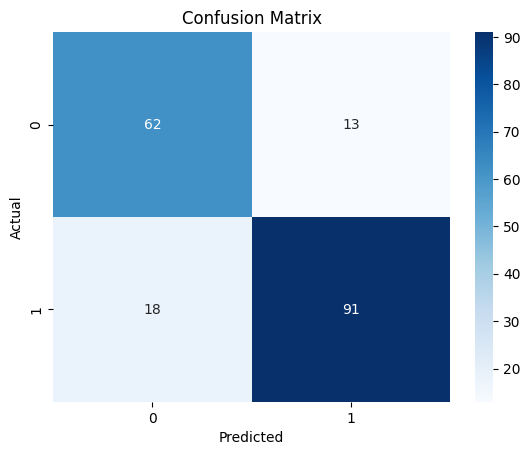

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,cp,0.162826
4,chol,0.148483
7,thalach,0.129028
0,age,0.108401
9,oldpeak,0.105216
3,trestbps,0.078636
8,exang,0.072523
1,sex,0.051431
12,thal,0.046704
11,ca,0.030589
